# Ripley's K and point functions to describe spatial data

#  intro

##  AnnData from MERFISH mouse cortex CSV 


In [1]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix
import scanpy as sc
import matplotlib.pyplot as plt

CSV_PATH = "/home/asalmona/Documents/Ricci/data/MERFISH_LUNA_small_cortex/MERFISH_mouse_cortex_test.csv"
CELL_SECTION = "mouse2_slice219"
sample_id = "mouse2_sample5"
N_GENE_COLS = 254


## after import

In [2]:
# Load CSV (first column is an index)
df = pd.read_csv(CSV_PATH, index_col=0)
print(df.shape)
print("First columns:", list(df.columns[:5]))
print("Last columns:", list(df.columns[-10:]))

# Filter one slice
df = df[df["cell_section"] == CELL_SECTION].copy()
print("After filtering:", df.shape)

# Transcriptome matrix = first N_GENE_COLS columns
gene_cols = list(df.columns[:N_GENE_COLS])

# Build X / var
X = csr_matrix(df[gene_cols].to_numpy(dtype=np.float32))
var = pd.DataFrame(index=gene_cols)

# Build obs with metadata + cell types
obs_cols = [
    "cell_name",
    "coord_X",
    "coord_Y",
    "class",
    "cell_class",
    "mouse",
    "sample_id",
    "cell_section",
]
obs = df[obs_cols].copy()

# Make sure types are categorical for plotting
for c in ["class", "cell_class", "mouse", "sample_id", "cell_section"]:
    obs[c] = pd.Categorical(obs[c])

# Use cell_name as obs_names if unique; otherwise keep the CSV index
if obs["cell_name"].is_unique:
    obs.index = obs["cell_name"].astype(str)

adata = ad.AnnData(X=X, obs=obs, var=var)
adata.obsm["spatial"] = obs[["coord_X", "coord_Y"]].to_numpy(dtype=np.float32)

adata

(118036, 262)
First columns: ['1700022I11Rik', '1810046K07Rik', '5031425F14Rik', '5730522E02Rik', 'Acta2']
Last columns: ['Penk', 'Gad1', 'cell_name', 'coord_X', 'coord_Y', 'class', 'cell_class', 'mouse', 'sample_id', 'cell_section']
After filtering: (3560, 262)


AnnData object with n_obs × n_vars = 3560 × 254
    obs: 'cell_name', 'coord_X', 'coord_Y', 'class', 'cell_class', 'mouse', 'sample_id', 'cell_section'
    obsm: 'spatial'

In [3]:
# Quick sanity checks
print(adata)
print("X shape:", adata.X.shape)
print("# genes kept:", adata.n_vars)
print("cell_section counts:\n", adata.obs["cell_section"].value_counts())

# Example: plot cell types in space (optional)
# import scanpy as sc
# sc.pl.spatial(adata, color="cell_class", spot_size=10, frameon=False)


AnnData object with n_obs × n_vars = 3560 × 254
    obs: 'cell_name', 'coord_X', 'coord_Y', 'class', 'cell_class', 'mouse', 'sample_id', 'cell_section'
    obsm: 'spatial'
X shape: (3560, 254)
# genes kept: 254
cell_section counts:
 cell_section
mouse2_slice219    3560
Name: count, dtype: int64


## comparing test and ground truth samples

here we will take a sample with prediction and ground truth and try to measure the correctness of the preidction with different metrics

In [4]:
pred = '/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_pred.csv'
ground_truth = '/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_true.csv'

# load the samples
whole_pred_sample = pd.read_csv(pred)
whole_ground_truth_sample = pd.read_csv(ground_truth)

# get only the VLMC cells
pred_sample = whole_pred_sample[whole_pred_sample['cell_class'] == 'VLMC']
ground_truth_sample = whole_ground_truth_sample[whole_ground_truth_sample['cell_class'] == 'VLMC']


In [5]:
# plot points of a particular cell type in space using matplotlib

def plot_cell_type(df, cell_type_value, cell_type_col="cell_class", x_col="coord_X", y_col="coord_Y"):
    subset = df[df[cell_type_col] == cell_type_value]
    plt.figure(figsize=(6, 6))
    plt.scatter(subset[x_col], subset[y_col], s=30, alpha=0.7)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'{cell_type_value} cells in spatial coordinates')
    plt.axis('equal')
    plt.show()

# Example usage:
# plot_cell_type(pred_sample, 'Astrocyte')

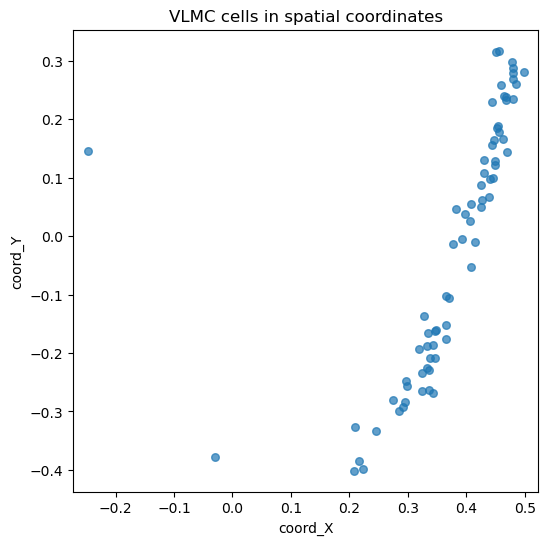

In [6]:
plot_cell_type(pred_sample, 'VLMC')

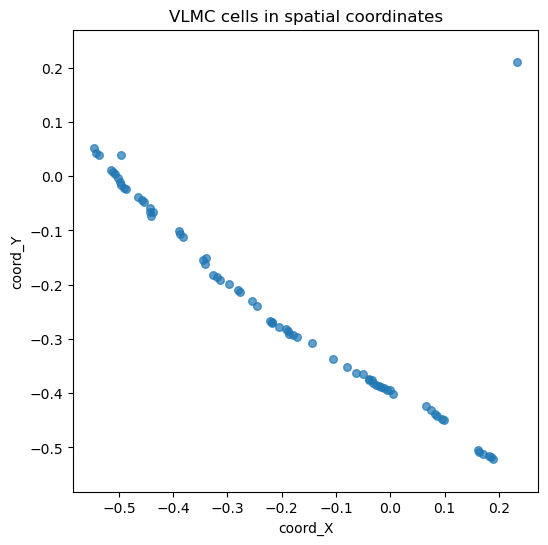

In [7]:
plot_cell_type(ground_truth_sample, 'VLMC')

## Aligning the prediction

In [8]:
import os, sys
# make the spectral_graph module importable from this notebook
_repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
_spectral_dir = os.path.join(_repo_root, "spectral-graph-entropy")
if _spectral_dir not in sys.path:
    sys.path.insert(0, _spectral_dir)

from ripley import align_prediction_rigid_to_ground_truth_by_id

# Rigidly align predicted coordinates to ground truth by cell ID
aligned_pred_sample = align_prediction_rigid_to_ground_truth_by_id(
    ground_truth_sample,
    pred_sample,
    cell_class_value='VLMC',
    id_col=0,
    coord_cols=('coord_X', 'coord_Y'),
    cell_class_col='cell_class',
    allow_reflection=False,
)

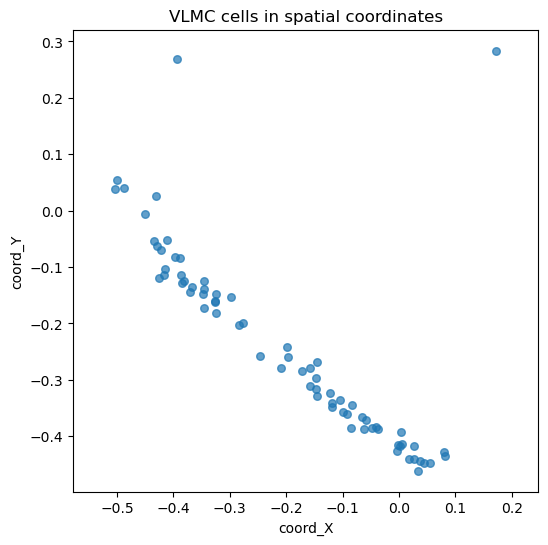

In [9]:
plot_cell_type(aligned_pred_sample, 'VLMC')

## Building reference samples (mean & artificial)

We build two extra point clouds that we will use as references when
comparing the prediction to the ground truth via Ripley's L and the
pair correlation function:

- **mean**: per-cell average of ground-truth and aligned-predicted coordinates
- **artificial**: a degenerate cloud (cells lined up along a diagonal + one isolated outlier)


In [10]:
# Mean point cloud: per-cell average of GT and aligned prediction
coords_gt = ground_truth_sample[['coord_X', 'coord_Y']].values
coords_pred = aligned_pred_sample[['coord_X', 'coord_Y']].values

mean_coords = np.mean([coords_gt, coords_pred], axis=0)

mean_coords_df = pd.DataFrame(mean_coords, columns=['coord_X', 'coord_Y'])
mean_coords_df['cell_class'] = 'VLMC'
mean_coords_df['cell_name'] = 'mean_coords'
mean_coords_df['sample_id'] = 'mean_coords'
mean_coords_df['cell_section'] = 'mean_coords'

# Artificial point cloud: cells evenly placed on a diagonal + one outlier
n_cells = len(ground_truth_sample)
print('n_cells:', n_cells)

start_x, end_x = -0.5, 0.07
start_y, end_y = 0.0, -0.5

rng = np.random.default_rng(0)
artificial_coords_x = np.linspace(start_x, end_x, n_cells - 1)
artificial_coords_y = np.linspace(start_y, end_y, n_cells - 1)
artificial_coords_x = artificial_coords_x + rng.normal(0, 0.001, n_cells - 1)
artificial_coords_y = artificial_coords_y + rng.normal(0, 0.001, n_cells - 1)
artificial_coords_x = np.append(artificial_coords_x, 0.2)
artificial_coords_y = np.append(artificial_coords_y, 0.2)

artificial_coords_df = pd.DataFrame(artificial_coords_x, columns=['coord_X'])
artificial_coords_df['coord_Y'] = artificial_coords_y
artificial_coords_df['cell_class'] = 'VLMC'
artificial_coords_df['cell_name'] = 'artificial_coords'
artificial_coords_df['sample_id'] = 'artificial_coords'
artificial_coords_df['cell_section'] = 'artificial_coords'

n_cells: 71


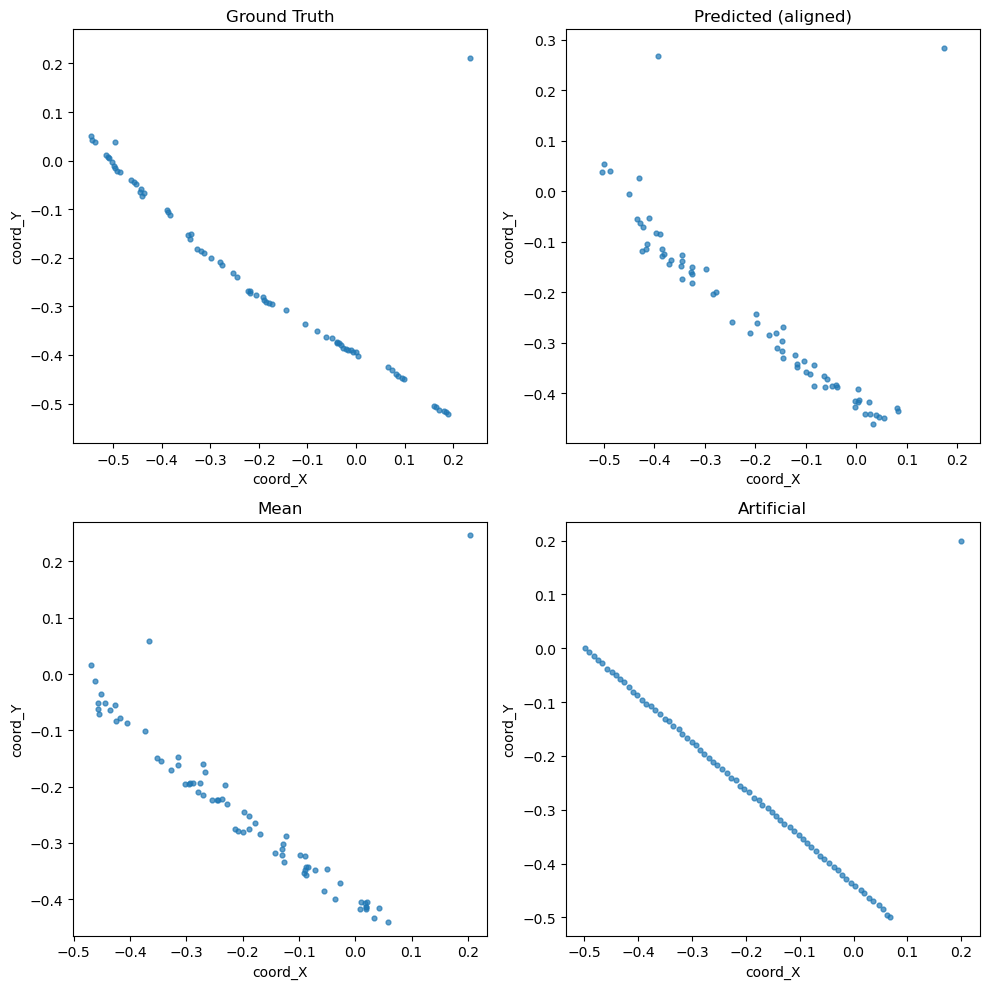

In [11]:
# Plot the four point distributions side by side
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for ax, df_, title in zip(
    axes,
    [ground_truth_sample, aligned_pred_sample, mean_coords_df, artificial_coords_df],
    ['Ground Truth', 'Predicted (aligned)', 'Mean', 'Artificial'],
):
    ax.scatter(df_['coord_X'], df_['coord_Y'], s=12, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('coord_X')
    ax.set_ylabel('coord_Y')
    ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

## Ripley's L and pair correlation curves on the four distributions

Instead of looking at a single radius, we sweep `radius` over a range
and plot the full curves of:

- **Besag's L function**, $L(r) = \sqrt{K(r)/\pi}$. For a
  homogeneous Poisson process $L(r) = r$, so deviations from the
  diagonal show clustering ($L(r) > r$) or regularity ($L(r) < r$).
- **Pair correlation function** $g(r)$, the analytic derivative of
  $K(r)$ smoothed with a Gaussian kernel. $g(r) = 1$ for CSR;
  peaks indicate characteristic inter-point distances.

This is the Ripley analogue of the radius-sweep we did for the
Cahn-Hilliard energy in `ch_energy_tests.ipynb`.

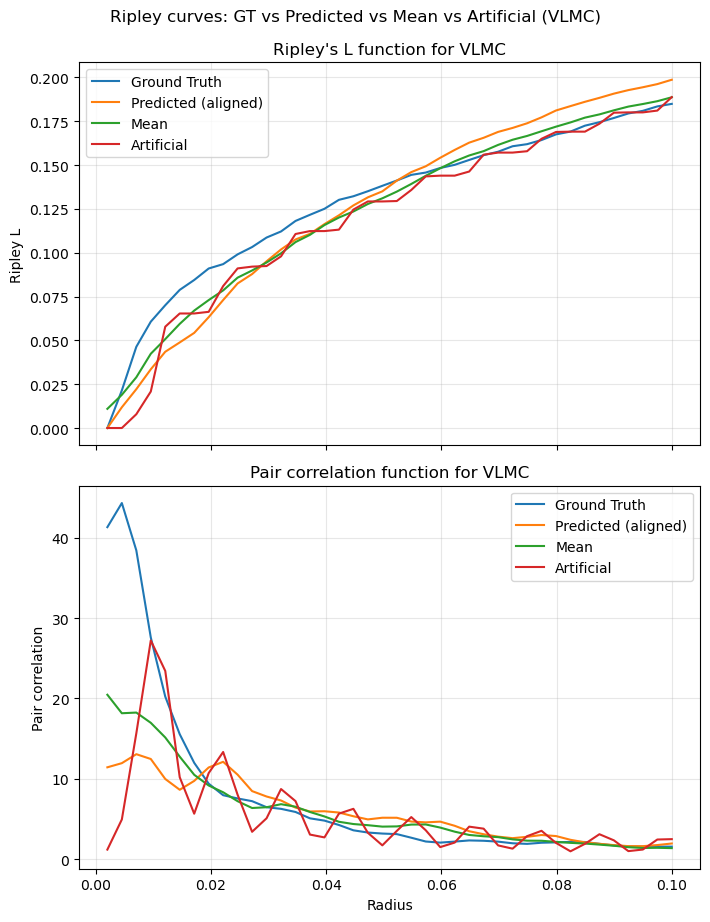

In [12]:
from ripley import (
    ripley_L_function,
    ripley_pair_correlation_function,
    plot_ripley_curves_multiple,
)

vlmc_dfs = [ground_truth_sample, aligned_pred_sample, mean_coords_df, artificial_coords_df]
vlmc_names = ['Ground Truth', 'Predicted (aligned)', 'Mean', 'Artificial']

# Pick a radius range that fits the spatial extent of the VLMC samples.
# VLMC coordinates roughly span ~1 unit, so we sweep small to ~10% of that.
fig, axs = plot_ripley_curves_multiple(
    (vlmc_dfs, vlmc_names),
    cell_type='VLMC',
    r_min=0.002,
    r_max=0.1,
    r_steps=40,
    scale=0.9,
)
fig.suptitle("Ripley curves: GT vs Predicted vs Mean vs Artificial (VLMC)", y=1.02)
plt.show()

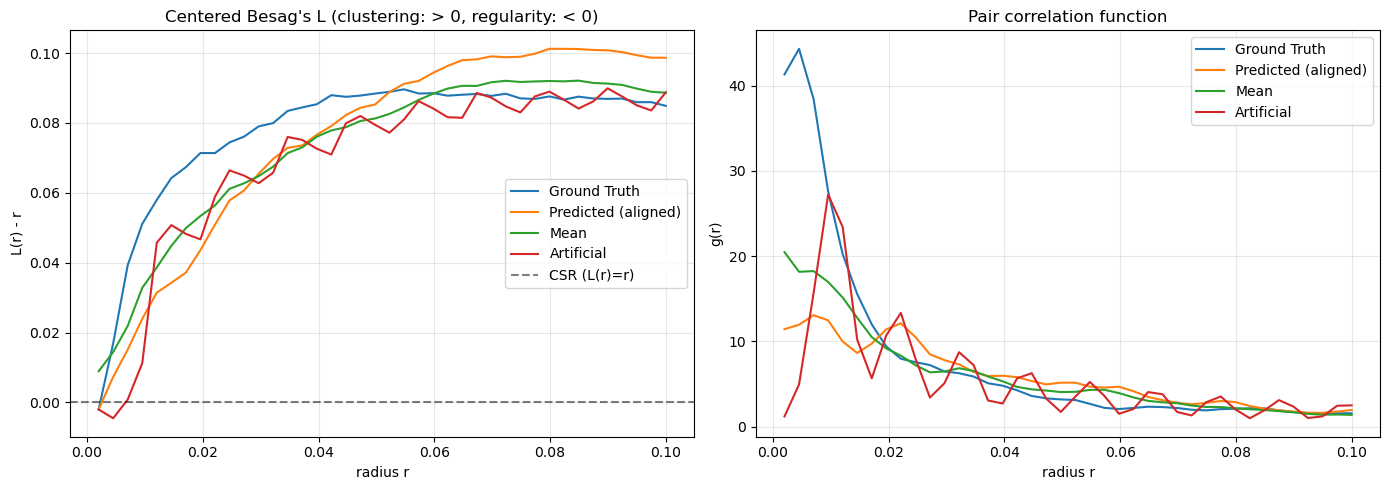

In [ ]:
# L function with the Poisson reference L(r) = r for context
radii_vlmc = np.linspace(0.002, 0.1, 40)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for df_, name in zip(vlmc_dfs, vlmc_names):
    L = ripley_L_function(df_, 'VLMC', radii_vlmc)
    axs[0].plot(radii_vlmc, L - radii_vlmc, label=name)

axs[0].axhline(0, color='k', linestyle='--', alpha=0.5, label='CSR (L(r)=r)')
axs[0].set_xlabel('radius r')
axs[0].set_ylabel('L(r) - r')
axs[0].set_title("Centered Besag's L (clustering: > 0, regularity: < 0)")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

bw_vlmc = float(np.median(np.diff(radii_vlmc)))
for df_, name in zip(vlmc_dfs, vlmc_names):
    g = ripley_pair_correlation_function(df_, 'VLMC', radii_vlmc, bandwidth=bw_vlmc)
    axs[1].plot(radii_vlmc, g, label=name)

axs[1].set_xlabel('radius r')
axs[1].set_ylabel('g(r)')
axs[1].set_title('Pair correlation function')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Toy example: three disk-like distributions

Same toy as in `ch_energy_tests.ipynb`: three synthetic 2D point
clouds with comparable size but different "phase" structure. Useful
as a sanity check for the Ripley curves.

- **Uniform disk**: hard boundary, isotropic.
- **Gaussian**: isotropic 2D Gaussian (no hard boundary).
- **Disk + Gaussian tail**: 60% inside a disk, 40% in a halo just
  outside the disk's edge.

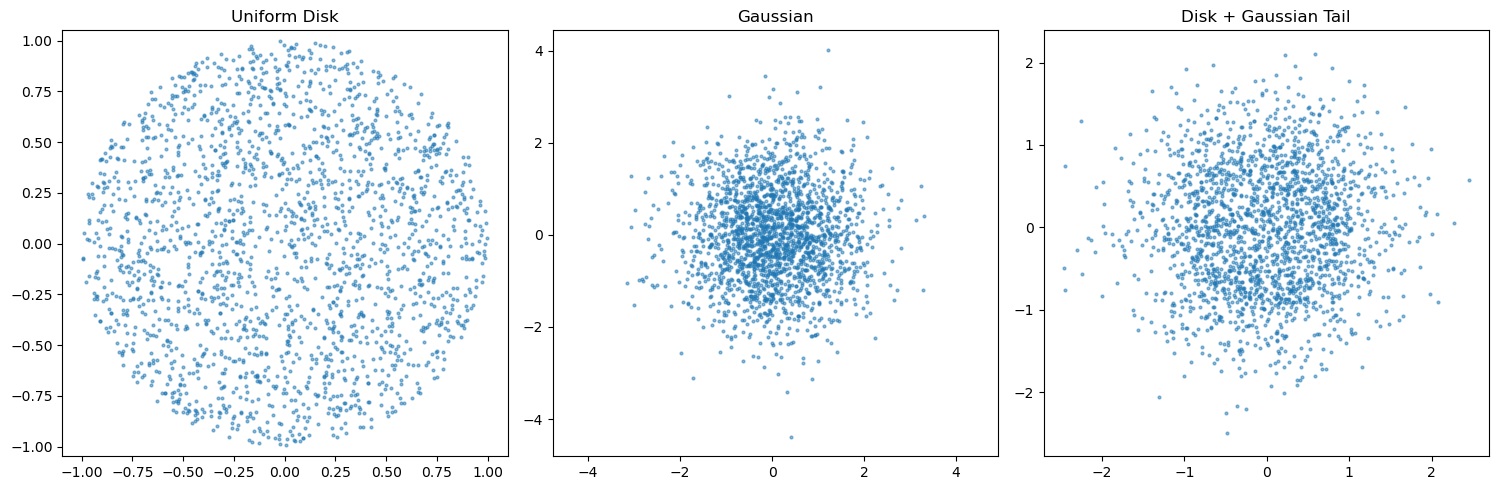

In [14]:
rng = np.random.default_rng(42)
n = 2048

# Uniform random disk with hard boundary
r = np.sqrt(rng.random(n))
theta = 2 * np.pi * rng.random(n)
disk_points = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)

# Isotropic 2D Gaussian
gaussian_points = rng.standard_normal((n, 2))

# Disk + Gaussian tail just outside the disk edge
n_disk = int(0.6 * n)
n_tail = n - n_disk

r_main = np.sqrt(rng.random(n_disk))
theta_main = 2 * np.pi * rng.random(n_disk)
disk_main = np.stack([r_main * np.cos(theta_main), r_main * np.sin(theta_main)], axis=1)

tail_radius_center = 1.0
tail_r = tail_radius_center + 0.5 * np.abs(rng.standard_normal(n_tail))
tail_theta = 2 * np.pi * rng.random(n_tail)
tail_points = np.stack([tail_r * np.cos(tail_theta), tail_r * np.sin(tail_theta)], axis=1)

disk_gauss_tail_points = np.concatenate([disk_main, tail_points], axis=0)

def _toy_df(points, name):
    out = pd.DataFrame(points, columns=['coord_X', 'coord_Y'])
    out['cell_class'] = 'VLMC'
    out['cell_name'] = name
    out['sample_id'] = name
    out['cell_section'] = name
    return out

disk_points_df = _toy_df(disk_points, 'disk_points')
gaussian_points_df = _toy_df(gaussian_points, 'gaussian_points')
disk_gauss_tail_points_df = _toy_df(disk_gauss_tail_points, 'disk_gauss_tail_points')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, pts, title in zip(
    axes,
    [disk_points, gaussian_points, disk_gauss_tail_points],
    ['Uniform Disk', 'Gaussian', 'Disk + Gaussian Tail'],
):
    ax.scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.5)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.show()

### Ripley curves on the toy distributions

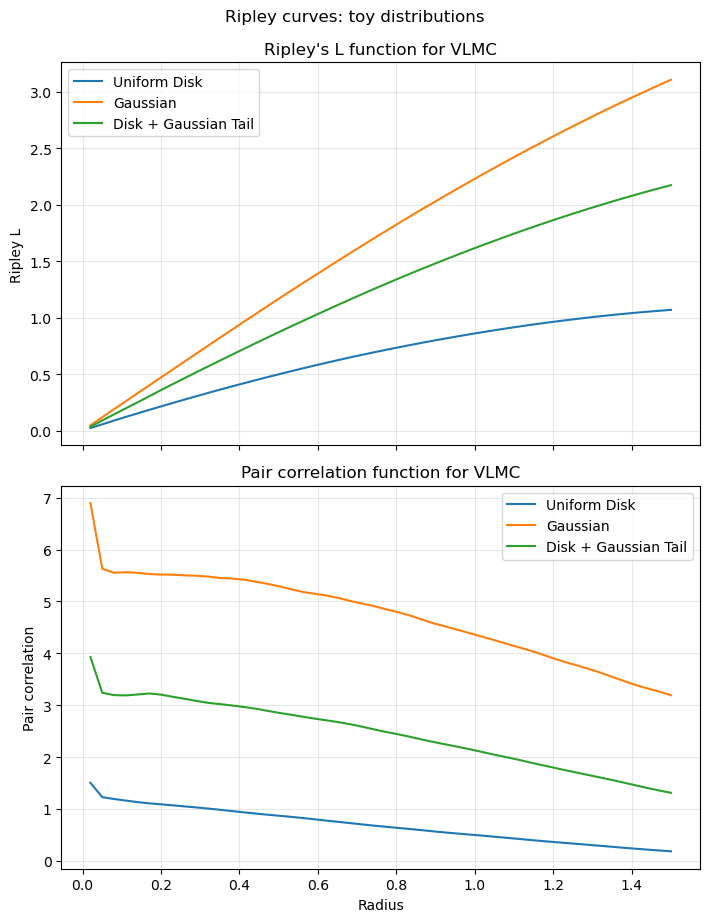

In [15]:
toy_dfs = [disk_points_df, gaussian_points_df, disk_gauss_tail_points_df]
toy_names = ['Uniform Disk', 'Gaussian', 'Disk + Gaussian Tail']

fig, axs = plot_ripley_curves_multiple(
    (toy_dfs, toy_names),
    cell_type='VLMC',
    r_min=0.02,
    r_max=1.5,
    r_steps=50,
    scale=0.9,
)
fig.suptitle("Ripley curves: toy distributions", y=1.02)
plt.show()

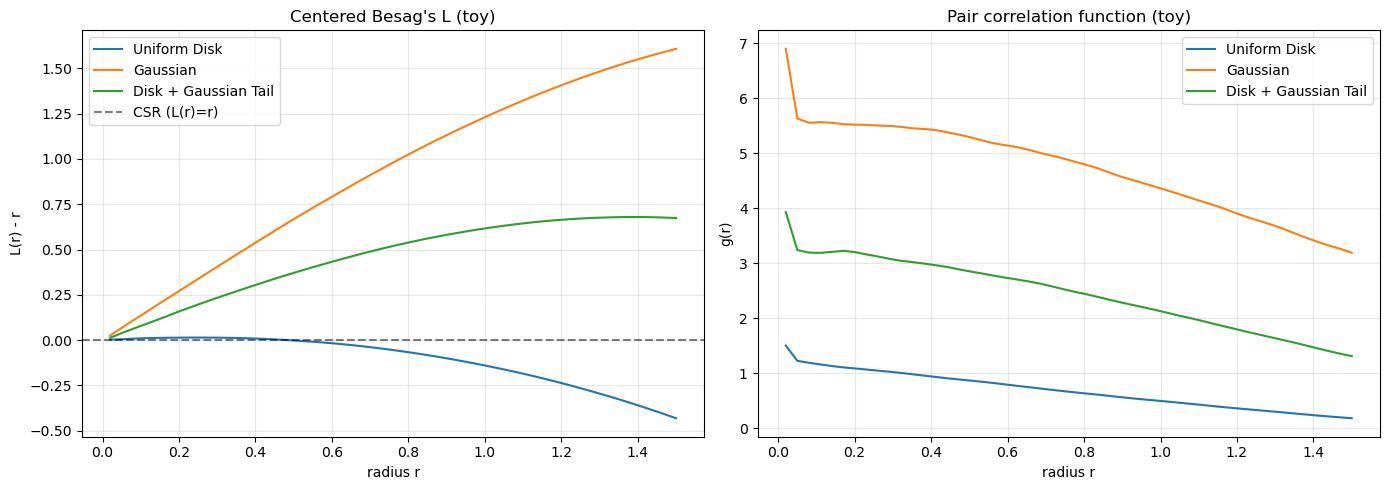

In [16]:
# Centered Besag's L (clustering: > 0, regularity: < 0) for the toy clouds
radii_toy = np.linspace(0.02, 1.5, 50)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for df_, name in zip(toy_dfs, toy_names):
    L = ripley_L_function(df_, 'VLMC', radii_toy)
    axs[0].plot(radii_toy, L - radii_toy, label=name)

axs[0].axhline(0, color='k', linestyle='--', alpha=0.5, label='CSR (L(r)=r)')
axs[0].set_xlabel('radius r')
axs[0].set_ylabel('L(r) - r')
axs[0].set_title("Centered Besag's L (toy)")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

bw_toy = float(np.median(np.diff(radii_toy)))
for df_, name in zip(toy_dfs, toy_names):
    g = ripley_pair_correlation_function(df_, 'VLMC', radii_toy, bandwidth=bw_toy)
    axs[1].plot(radii_toy, g, label=name)

axs[1].set_xlabel('radius r')
axs[1].set_ylabel('g(r)')
axs[1].set_title('Pair correlation function (toy)')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()